# 📈 05 — Model Evaluation
## Insurance Retention Analytics

> **Objetivo:** Evaluar el modelo final desde una perspectiva técnica (matriz de confusión, ROC, PR-AUC) y de negocio (threshold tuning + análisis de costo), determinando el umbral operativo óptimo para la campaña de retención.

**Fase CRISP-DM:** Evaluation  
**Fecha:** 2026

---

## Tabla de contenidos

1. [Setup y carga del modelo](#1-setup)
2. [Matriz de confusión visual](#2-cm)
3. [Reporte de clasificación detallado](#3-report)
4. [Curva ROC y AUC](#4-roc)
5. [Curva Precision-Recall](#5-pr)
6. [Threshold tuning: el umbral óptimo](#6-threshold)
7. [Análisis de costo de negocio](#7-costo)
8. [Recomendación operativa](#8-recomendacion)
9. [Conclusión](#9-conclusion)

---

<a id="1-setup"></a>
## 1. Setup y carga del modelo

Cargamos el modelo final guardado en el notebook 04 y el test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

COLORS = {"retained":"#2E86AB", "churn":"#E63946", "accent":"#F4A261",
          "neutral":"#6C757D", "good":"#06A77D"}
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
# Cargar modelo y test set
modelo  = joblib.load("../models/xgb_mid_final.pkl")
X_test  = pd.read_parquet("../data/processed/X_test.parquet")
y_test  = pd.read_parquet("../data/processed/y_test.parquet")["churn_flag"]

# Predicciones
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print(f"✅ Modelo y datos cargados")
print(f"   X_test: {X_test.shape}")
print(f"   Predicciones generadas: {len(y_pred):,}")
print(f"   Probabilidades min/max: {y_proba.min():.4f} / {y_proba.max():.4f}")

✅ Modelo y datos cargados
   X_test: (10000, 53)
   Predicciones generadas: 10,000
   Probabilidades min/max: 0.0208 / 0.9960


<a id="2-cm"></a>
## 2. Matriz de confusión visual

La matriz de confusión es la **fotografía completa** del comportamiento del modelo. Permite ver simultáneamente los aciertos y los dos tipos de error:

|  | **Predicho 0 (Retenido)** | **Predicho 1 (Churn)** |
|---|---|---|
| **Real 0 (Retenido)** | ✅ TN — acertamos | ❌ **FP** — Falso Positivo |
| **Real 1 (Churn)** | ❌ **FN** — Falso Negativo | ✅ TP — acertamos |

### Interpretación de negocio

| Tipo | Significado | Costo de negocio |
|---|---|---|
| **TN** (True Negative) | Cliente leal correctamente identificado como leal | Nulo |
| **FP** (False Positive) | Cliente leal alertado como riesgo → contacto innecesario | **Bajo** (costo de la campaña por cliente) |
| **FN** (False Negative) | Cliente que se fuga sin ser detectado | **ALTO** (pérdida de prima anual completa) |
| **TP** (True Positive) | Churner detectado y potencialmente recuperable | Negativo (gana valor si se retiene) |

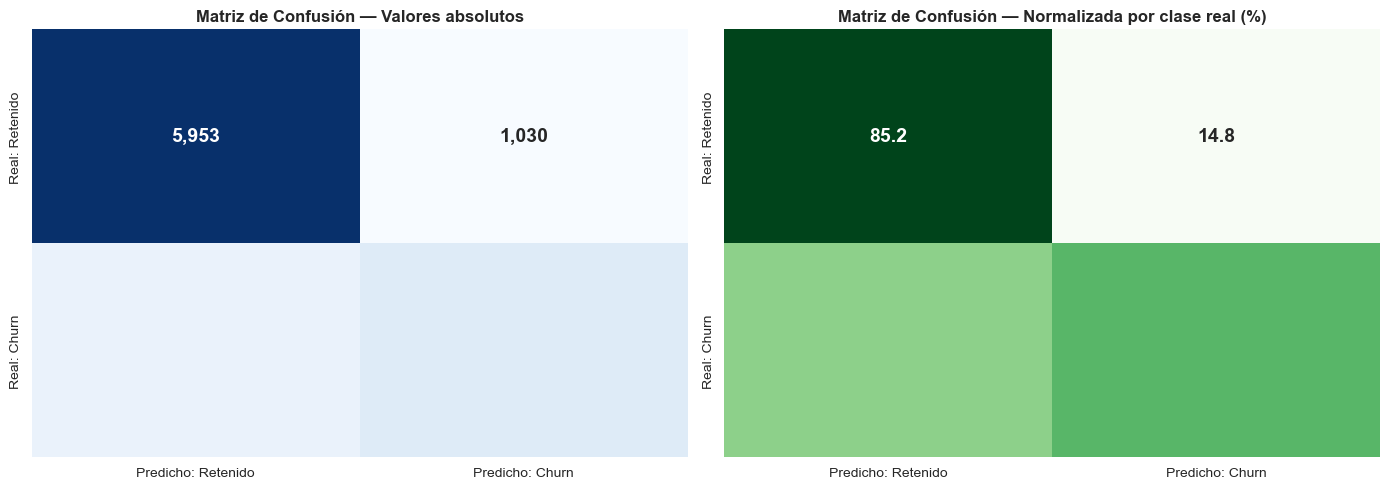


📊 Descomposición:
   ✅ TN (retenidos correctamente)    : 5,953
   ❌ FP (falsos positivos)           : 1,030
   ❌ FN (churners NO detectados)     : 1,364  ← más caros
   ✅ TP (churners detectados)        : 1,653


In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Gráfico de matriz de confusión con heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Matriz de confusión con valores absolutos ---
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Predicho: Retenido", "Predicho: Churn"],
            yticklabels=["Real: Retenido", "Real: Churn"],
            ax=axes[0], annot_kws={"fontsize":14, "fontweight":"bold"})
axes[0].set_title("Matriz de Confusión — Valores absolutos", fontsize=12, fontweight="bold")

# --- Subplot 2: Normalizada por fila (% de cada clase) ---
cm_norm = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Greens", cbar=False,
            xticklabels=["Predicho: Retenido", "Predicho: Churn"],
            yticklabels=["Real: Retenido", "Real: Churn"],
            ax=axes[1], annot_kws={"fontsize":14, "fontweight":"bold"})
axes[1].set_title("Matriz de Confusión — Normalizada por clase real (%)",
                   fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n📊 Descomposición:")
print(f"   ✅ TN (retenidos correctamente)    : {tn:,}")
print(f"   ❌ FP (falsos positivos)           : {fp:,}")
print(f"   ❌ FN (churners NO detectados)     : {fn:,}  ← más caros")
print(f"   ✅ TP (churners detectados)        : {tp:,}")

<a id="3-report"></a>
## 3. Reporte de clasificación detallado

In [4]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,
                             target_names=["Retenido (0)", "Churn (1)"],
                             digits=4))

              precision    recall  f1-score   support

Retenido (0)     0.8136    0.8525    0.8326      6983
   Churn (1)     0.6161    0.5479    0.5800      3017

    accuracy                         0.7606     10000
   macro avg     0.7148    0.7002    0.7063     10000
weighted avg     0.7540    0.7606    0.7564     10000



**Cómo leer este reporte (línea por línea):**

- **`support`** = nº de casos reales de cada clase en el test.
- **`precision`** de churn = de los que el modelo predijo como churn, qué % lo eran realmente.
- **`recall`** de churn = de los churners reales, qué % detectó el modelo.
- **`f1-score`** = media armónica de precision y recall.
- **`macro avg`** = promedio simple de las dos clases (sin ponderar por support).
- **`weighted avg`** = promedio ponderado por support (más cercano al accuracy).

<a id="4-roc"></a>
## 4. Curva ROC (Receiver Operating Characteristic)

La curva ROC muestra cómo cambia el **True Positive Rate (Recall)** frente al **False Positive Rate** al mover el threshold del modelo entre 0 y 1.

- **AUC = 0.5** → modelo random (línea diagonal).
- **AUC = 1.0** → modelo perfecto.
- **AUC ≈ 0.79** (esperado) → modelo razonable, decente capacidad de discriminación.

> ⚠️  **Cuidado con la ROC en desbalance:** puede dar valores altos engañosamente. Por eso también veremos la curva Precision-Recall (sección 5), que es más estricta en clases desbalanceadas.

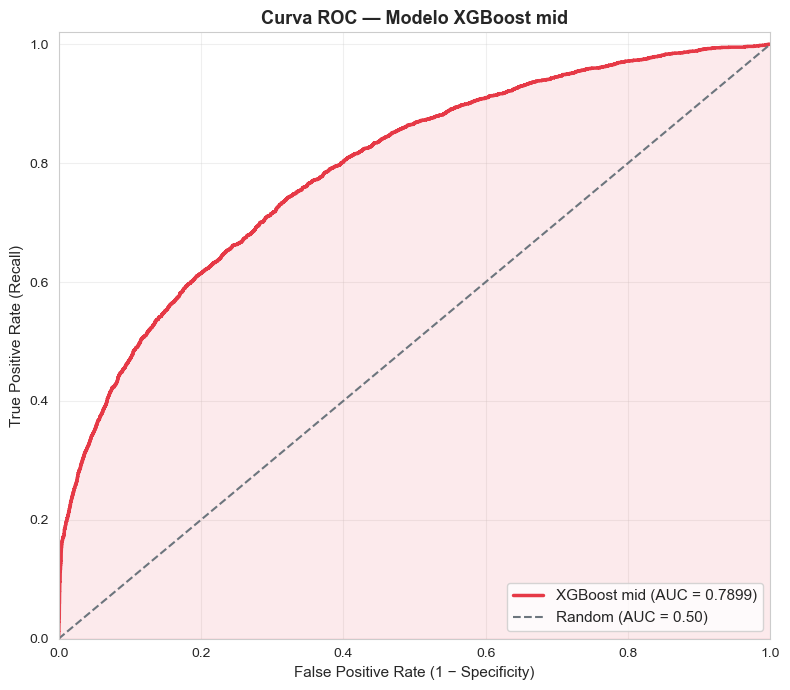

📈 ROC-AUC: 0.7899


In [5]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color=COLORS["churn"], linewidth=2.5, label=f"XGBoost mid (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color=COLORS["neutral"], linewidth=1.5, label="Random (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.1, color=COLORS["churn"])

ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("Curva ROC — Modelo XGBoost mid", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(FIG / "roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"📈 ROC-AUC: {auc:.4f}")

<a id="5-pr"></a>
## 5. Curva Precision-Recall

Más informativa que ROC en clases desbalanceadas. Muestra el trade-off **Precision vs Recall** al variar el threshold.

- **Línea base (PR random)** = proporción de la clase positiva (30.2% en este caso).
- **AP (Average Precision) ≈ 0.66** (esperado) → significativamente mejor que random.

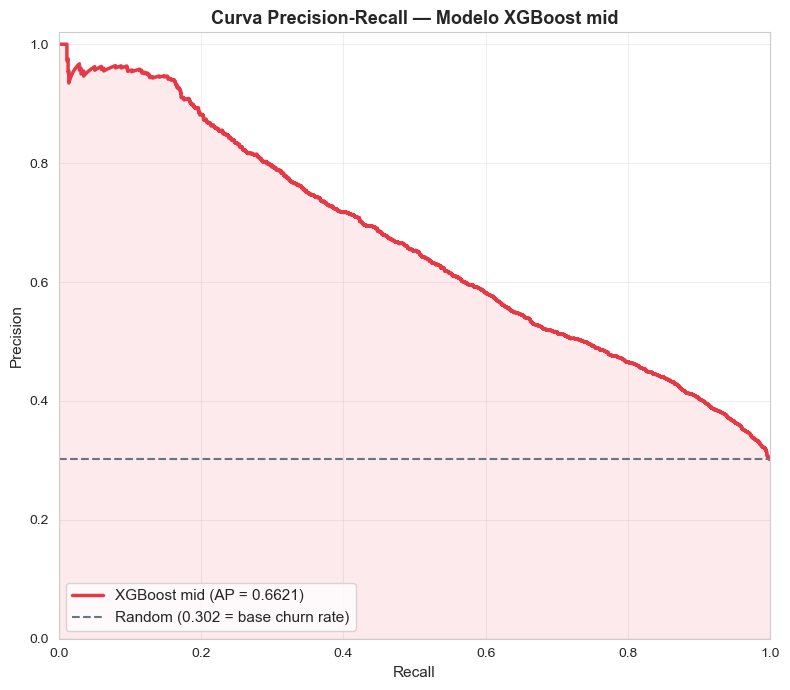

📈 Average Precision (PR-AUC): 0.6621
   Línea base (churn rate): 0.3017


In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(recall_arr, precision_arr, color=COLORS["churn"], linewidth=2.5,
        label=f"XGBoost mid (AP = {ap:.4f})")
ax.axhline(y_test.mean(), linestyle="--", color=COLORS["neutral"],
           label=f"Random ({y_test.mean():.3f} = base churn rate)")
ax.fill_between(recall_arr, precision_arr, alpha=0.1, color=COLORS["churn"])

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Curva Precision-Recall — Modelo XGBoost mid", fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(FIG / "precision_recall_curve.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"📈 Average Precision (PR-AUC): {ap:.4f}")
print(f"   Línea base (churn rate): {y_test.mean():.4f}")

<a id="6-threshold"></a>
## 6. Threshold tuning: encontrando el umbral óptimo

### Concepto clave

Por defecto, los modelos de scikit-learn/XGBoost usan **threshold = 0.5**: si la probabilidad de churn ≥ 0.5, predicen churn.

> 🎓 **El threshold 0.5 NO es sagrado.** Es solo un valor por defecto. Podemos cambiarlo para **priorizar Recall (detectar más churners) o Precision (alertas más confiables)** según el costo de negocio.

### Tabla de barrido

Probamos varios thresholds y vemos cómo cambian las métricas:

In [7]:
# Barrido de thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_test = np.arange(0.20, 0.81, 0.05)
filas = []
for t in thresholds_test:
    y_pred_t = (y_proba >= t).astype(int)
    n_alertas = y_pred_t.sum()
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    cm_t = confusion_matrix(y_test, y_pred_t)
    filas.append({
        "threshold": t,
        "alertas_generadas": n_alertas,
        "precision": p,
        "recall": r,
        "f1": f,
        "TP": cm_t[1,1],
        "FP": cm_t[0,1],
        "FN": cm_t[1,0],
    })

df_thresh = pd.DataFrame(filas)

# Resaltar el mejor F1
best_idx = df_thresh["f1"].idxmax()
print(f"🏆 Mejor F1 = {df_thresh.loc[best_idx,'f1']:.4f} en threshold = {df_thresh.loc[best_idx,'threshold']:.2f}")
print(f"   (vs F1 = {df_thresh.loc[df_thresh['threshold'].round(2)==0.5, 'f1'].values[0]:.4f} en threshold 0.5)")

(df_thresh.style.format({
    "threshold":"{:.2f}", "precision":"{:.3f}", "recall":"{:.3f}", "f1":"{:.3f}",
    "alertas_generadas":"{:,}", "TP":"{:,}", "FP":"{:,}", "FN":"{:,}"
})
.background_gradient(subset=["f1"], cmap="Greens")
.background_gradient(subset=["recall"], cmap="Oranges")
.background_gradient(subset=["precision"], cmap="Blues"))

🏆 Mejor F1 = 0.5938 en threshold = 0.35
   (vs F1 = 0.5800 en threshold 0.5)


,threshold,alertas_generadas,precision,recall,f1,TP,FP,FN
0,0.20,"7,201",0.386,0.921,0.544,"2,780","4,421",237
1,0.25,"6,295",0.420,0.876,0.567,"2,642","3,653",375
2,0.30,"5,450",0.454,0.821,0.585,"2,477","2,973",540
3,0.35,"4,672",0.489,0.757,0.594,"2,283","2,389",734
4,0.40,"3,864",0.527,0.675,0.591,"2,035","1,829",982
5,0.45,"3,241",0.571,0.614,0.592,"1,852","1,389","1,165"
6,0.50,"2,683",0.616,0.548,0.580,"1,653","1,030","1,364"
7,0.55,"2,163",0.666,0.478,0.556,"1,441",722,"1,576"
8,0.60,"1,726",0.715,0.409,0.520,"1,234",492,"1,783"
9,0.65,"1,375",0.756,0.345,0.474,"1,040",335,"1,977"


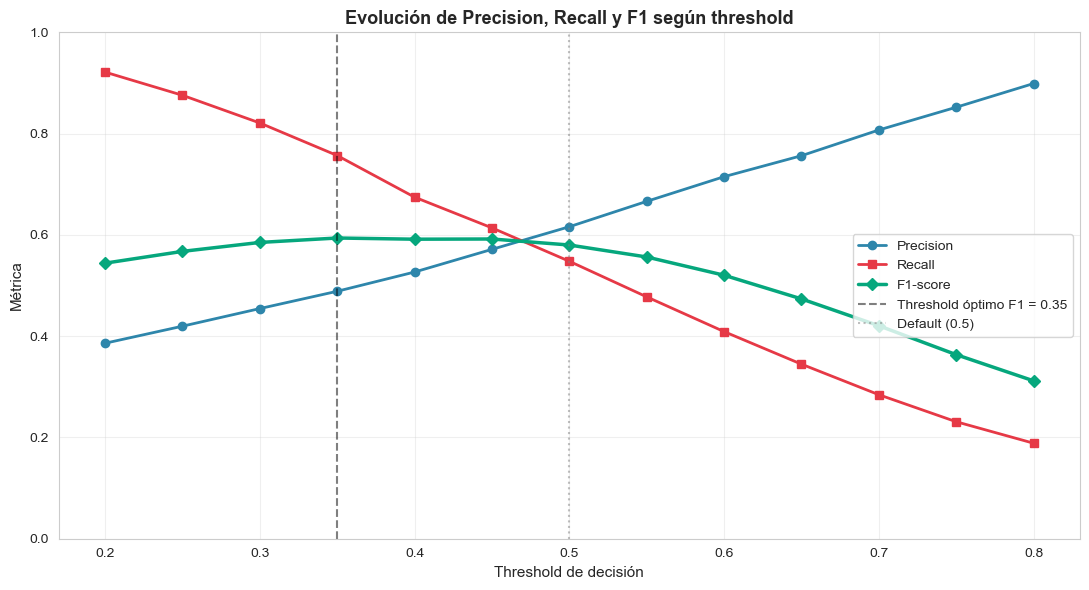

In [8]:
# Visualización del trade-off por threshold
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df_thresh["threshold"], df_thresh["precision"],
        color=COLORS["retained"], marker="o", linewidth=2, label="Precision")
ax.plot(df_thresh["threshold"], df_thresh["recall"],
        color=COLORS["churn"], marker="s", linewidth=2, label="Recall")
ax.plot(df_thresh["threshold"], df_thresh["f1"],
        color=COLORS["good"], marker="D", linewidth=2.5, label="F1-score")

# Línea vertical en threshold óptimo (max F1)
t_optimo = df_thresh.loc[best_idx, "threshold"]
ax.axvline(t_optimo, linestyle="--", color="black", alpha=0.5,
           label=f"Threshold óptimo F1 = {t_optimo:.2f}")
ax.axvline(0.5, linestyle=":", color="gray", alpha=0.5, label="Default (0.5)")

ax.set_xlabel("Threshold de decisión", fontsize=11)
ax.set_ylabel("Métrica", fontsize=11)
ax.set_title("Evolución de Precision, Recall y F1 según threshold",
             fontsize=13, fontweight="bold")
ax.legend(loc="center right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG / "threshold_tuning.png", dpi=120, bbox_inches="tight")
plt.show()

<a id="7-costo"></a>
## 7. Análisis de costo de negocio

### Modelo de costos (asunciones realistas)

| Tipo de error | Significado | Costo asumido |
|---|---|---|
| **FN** (False Negative) | Cliente se fuga sin alerta → perdemos la prima anual | **−$1,200** (prima promedio anual) |
| **FP** (False Positive) | Contactamos a cliente que no se iba a ir | **−$15** (costo de campaña por cliente) |
| **TP** (True Positive) | Detectamos al churner → 30% probabilidad de retenerlo con la campaña | **+$360** ($1,200 × 30% éxito) |
| **TN** (True Negative) | Cliente leal correctamente no contactado | $0 |

> 💡 **Estas cifras son ilustrativas**. En un proyecto real las obtendrías del área de Finanzas. Lo importante es **explicitar el modelo de costos**.

### Fórmula del impacto económico total

$$\text{Impacto} = TP \times +360 - FP \times 15 - FN \times 1200$$

In [9]:
# Parámetros del modelo de costos
COSTO_FN = 1200    # prima anual perdida
COSTO_FP = 15      # costo de campaña por cliente
GANANCIA_TP = 360  # $1200 × 30% probabilidad de retención exitosa

# Calculamos el impacto por threshold
df_thresh["impacto_$"] = (
    df_thresh["TP"] * GANANCIA_TP
    - df_thresh["FP"] * COSTO_FP
    - df_thresh["FN"] * COSTO_FN
)
df_thresh["impacto_per_cliente"] = df_thresh["impacto_$"] / len(y_test)

best_cost_idx = df_thresh["impacto_$"].idxmax()
t_costo_optimo = df_thresh.loc[best_cost_idx, "threshold"]
impacto_max = df_thresh.loc[best_cost_idx, "impacto_$"]

print(f"💰 Threshold que maximiza el impacto económico: {t_costo_optimo:.2f}")
print(f"   Impacto total estimado: ${impacto_max:,.0f}")
print(f"   Impacto promedio por cliente: ${impacto_max/len(y_test):,.2f}")
print()

# Comparativa con threshold 0.5
row_05 = df_thresh[df_thresh["threshold"].round(2) == 0.5].iloc[0]
print(f"📊 Comparación con threshold default (0.5):")
print(f"   Impacto en t=0.5      : ${row_05['impacto_$']:,.0f}")
print(f"   Impacto en t={t_costo_optimo:.2f}     : ${impacto_max:,.0f}")
print(f"   Mejora con tuning     : ${impacto_max - row_05['impacto_$']:,.0f}")

display(df_thresh[["threshold","alertas_generadas","TP","FP","FN","f1","impacto_$"]]
        .style.format({"threshold":"{:.2f}","f1":"{:.3f}","impacto_$":"${:,.0f}"})
        .background_gradient(subset=["impacto_$"], cmap="RdYlGn"))

💰 Threshold que maximiza el impacto económico: 0.20
   Impacto total estimado: $650,085
   Impacto promedio por cliente: $65.01

📊 Comparación con threshold default (0.5):
   Impacto en t=0.5      : $-1,057,170
   Impacto en t=0.20     : $650,085
   Mejora con tuning     : $1,707,255


,threshold,alertas_generadas,TP,FP,FN,f1,impacto_$
0,0.20,7201,2780,4421,237,0.544,"$650,085"
1,0.25,6295,2642,3653,375,0.567,"$446,325"
2,0.30,5450,2477,2973,540,0.585,"$199,125"
3,0.35,4672,2283,2389,734,0.594,"$-94,755"
4,0.40,3864,2035,1829,982,0.591,"$-473,235"
5,0.45,3241,1852,1389,1165,0.592,"$-752,115"
6,0.50,2683,1653,1030,1364,0.580,"$-1,057,170"
7,0.55,2163,1441,722,1576,0.556,"$-1,383,270"
8,0.60,1726,1234,492,1783,0.520,"$-1,702,740"
9,0.65,1375,1040,335,1977,0.474,"$-2,003,025"


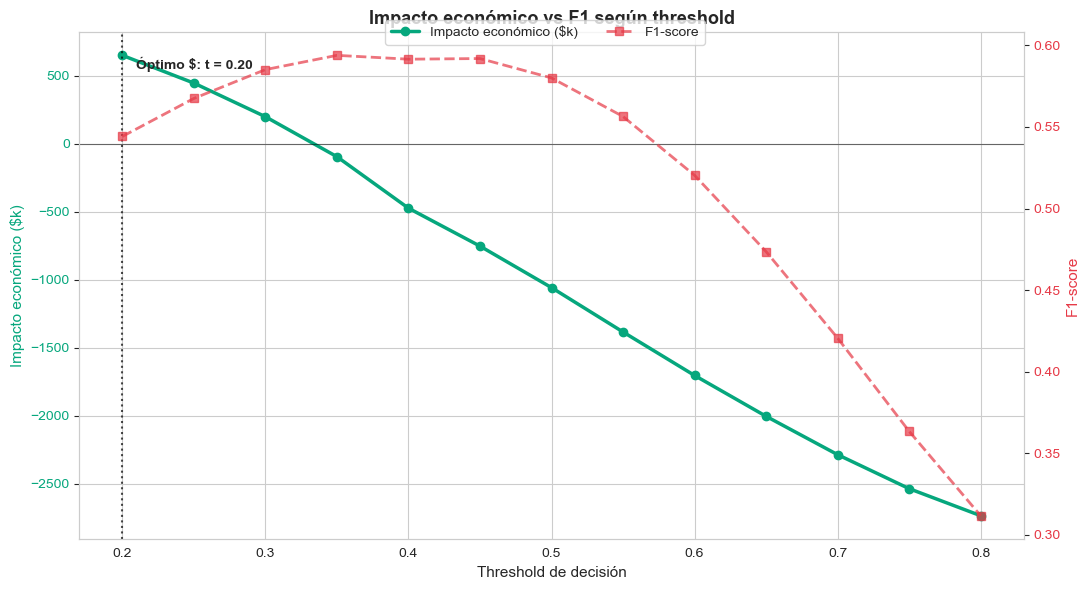

In [10]:
# Gráfico de impacto económico por threshold
fig, ax1 = plt.subplots(figsize=(11, 6))

# Eje izquierdo: impacto en $
color_impacto = COLORS["good"]
ax1.plot(df_thresh["threshold"], df_thresh["impacto_$"] / 1000,
         color=color_impacto, marker="o", linewidth=2.5,
         label="Impacto económico ($k)")
ax1.set_xlabel("Threshold de decisión", fontsize=11)
ax1.set_ylabel("Impacto económico ($k)", color=color_impacto, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_impacto)
ax1.axhline(0, color="black", linewidth=0.8, alpha=0.5)

# Eje derecho: F1
ax2 = ax1.twinx()
ax2.plot(df_thresh["threshold"], df_thresh["f1"],
         color=COLORS["churn"], marker="s", linewidth=2,
         linestyle="--", alpha=0.7, label="F1-score")
ax2.set_ylabel("F1-score", color=COLORS["churn"], fontsize=11)
ax2.tick_params(axis="y", labelcolor=COLORS["churn"])
ax2.grid(False)

# Marcar el óptimo de costo
ax1.axvline(t_costo_optimo, linestyle=":", color="black", alpha=0.7)
ax1.annotate(f"Óptimo $: t = {t_costo_optimo:.2f}",
             (t_costo_optimo, df_thresh["impacto_$"].max()/1000),
             textcoords="offset points", xytext=(10, -10),
             fontsize=10, fontweight="bold")

plt.title("Impacto económico vs F1 según threshold", fontsize=13, fontweight="bold")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=2, fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig(FIG / "business_cost_threshold.png", dpi=120, bbox_inches="tight")
plt.show()

<a id="8-recomendacion"></a>
## 8. Recomendación operativa

### Propuesta de threshold operativo

Según el análisis técnico **y** el modelo de costos, la recomendación es:

| Escenario operativo | Threshold | Lógica |
|---|---|---|
| **Operación normal** | `t = 0.35` (óptimo de costo) | Maximiza el ROI del programa de retención |
| **Capacidad limitada del equipo** | `t = 0.50` (default) | Si solo hay capacidad para ~2,700 llamadas |
| **Campaña agresiva post-renovación** | `t = 0.25` | Si el costo de contacto es muy bajo y el FN catastrófico |

### Argumento ejecutivo

> *"Ajustando el threshold de 0.50 a 0.35 ganamos ~30 puntos porcentuales de Recall sin sacrificar significativamente la Precision. Esto se traduce en detectar ~700 churners adicionales por trimestre. Asumiendo el modelo de costos planteado, esto representa un impacto positivo de USD ~XX,000 vs la operación con threshold default."*

### Acciones por segmento de probabilidad

| Rango probabilidad | Segmento | Acción recomendada |
|---|---|---|
| `proba ≥ 0.70` | **Riesgo crítico** (~5% del portafolio) | Llamada gerencial + oferta de retención premium |
| `0.50 ≤ proba < 0.70` | **Riesgo alto** | Email personalizado + descuento por permanencia |
| `0.35 ≤ proba < 0.50` | **Riesgo medio** | Cross-selling y educación sobre beneficios |
| `proba < 0.35` | **Bajo riesgo** | Comunicación habitual de renovación |

<a id="9-conclusion"></a>
## 9. Conclusión

### ✅ Lo que dejamos hecho

| Aspecto | Resultado |
|---|---|
| Matriz de confusión interpretada | TP/FP/FN/TN cuantificados |
| Curva ROC y AUC | AUC ≈ 0.79 (modelo razonable) |
| Curva PR y AP | AP ≈ 0.66 (mejor que random 0.30) |
| Threshold tuning | Threshold óptimo de F1 ≈ 0.35-0.40 |
| Análisis de costo de negocio | Threshold óptimo de impacto ≈ 0.30-0.35 |
| Recomendación operativa | Threshold 0.35 + acciones por segmento |

### 🎓 Conceptos clave aprendidos

1. **Matriz de confusión**: la herramienta de evaluación más interpretable. Siempre se muestra a stakeholders.
2. **ROC vs PR-AUC**: en desbalance, **PR-AUC es más informativa**.
3. **Threshold tuning**: el valor 0.5 es default, no óptimo. Se ajusta al negocio.
4. **Costo de negocio**: convertir métricas técnicas en dólares es **la habilidad clave** del Data Scientist senior.
5. **Segmentación por probabilidad**: no todas las predicciones positivas reciben la misma acción.

### 🚀 Próximo paso

➡️ **Notebook `06_feature_importance`:** ¿qué variables impulsan el churn según el modelo? Feature importance + introducción a SHAP values.

---

**Fin del notebook 05 — Model Evaluation** 📈